In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, precision_score, f1_score, recall_score
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.pipeline import make_pipeline as imb_make_pipeline
import numpy as np
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV




In [2]:
files = [
    "/home/truphile/Downloads/classification data/data_descriptions.csv",
    "/home/truphile/Downloads/classification data/train.csv",
    "/home/truphile/Downloads/classification data/test.csv"
]

datasets = [pd.read_csv(file) for file in files]

data, train, test = datasets
data.head()

,Column_name,Column_type,Data_type,Description
0,AccountAge,Feature,integer,The age of the user's account in months.
1,MonthlyCharges,Feature,float,The amount charged to the user on a monthly ba...
2,TotalCharges,Feature,float,The total charges incurred by the user over th...
3,SubscriptionType,Feature,object,The type of subscription chosen by the user (B...
4,PaymentMethod,Feature,string,The method of payment used by the user.


In [3]:
train.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,...,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,...,18,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,...,23,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,...,30,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,...,20,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0


In [4]:
train["Churn"].value_counts()

Churn
0    199605
1     44182
Name: count, dtype: int64

In [5]:
train["Churn"].value_counts(normalize=True) * 100 #check percentage for value_count

Churn
0    81.876802
1    18.123198
Name: proportion, dtype: float64

In [6]:
train.isnull()
train.drop_duplicates()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,...,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,...,18,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,...,23,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,...,30,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,...,20,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243782,77,9.639902,742.272460,Basic,Mailed check,No,Movies,No,Computer,13.502729,...,47,Sci-Fi,3.697451,1,Male,8,Yes,No,FBZ38J108Z,0
243783,117,13.049257,1526.763053,Premium,Credit card,No,TV Shows,Yes,TV,24.963291,...,35,Comedy,1.449742,4,Male,20,No,No,W4AO1Y6NAI,0
243784,113,14.514569,1640.146267,Premium,Credit card,Yes,TV Shows,No,TV,10.628728,...,44,Action,4.012217,6,Male,13,Yes,Yes,0H3SWWI7IU,0
243785,7,18.140555,126.983887,Premium,Bank transfer,Yes,TV Shows,No,TV,30.466782,...,36,Fantasy,2.135789,7,Female,5,No,Yes,63SJ44RT4A,0


In [7]:
correlation = train.corr(numeric_only=True)
correlation["Churn"].sort_values(ascending=False)  # corelation check (0.5 - 1 = shows there is a strong positive correlation),(0.1 - 0.4 = shows there is a weak positive correlation)
                                                   # corelation check (-0.5 - 1 = shows there is a strong negative correlation),(-0.1 - -0.4 = shows there is a weak negative correlation)

Churn                       1.000000
MonthlyCharges              0.100473
SupportTicketsPerMonth      0.084064
UserRating                  0.022124
WatchlistSize               0.021739
TotalCharges               -0.120529
ViewingHoursPerWeek        -0.128645
ContentDownloadsPerMonth   -0.129752
AverageViewingDuration     -0.146897
AccountAge                 -0.197736
Name: Churn, dtype: float64

In [8]:
train.drop(columns="CustomerID")

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,63.531377,10,Sci-Fi,2.176498,4,Male,3,No,No,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,25.725595,18,Action,3.478632,8,Male,23,No,Yes,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,57.364061,23,Fantasy,4.238824,6,Male,1,Yes,Yes,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,131.537507,30,Drama,4.276013,2,Male,24,Yes,Yes,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,45.356653,20,Comedy,3.616170,4,Female,0,No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243782,77,9.639902,742.272460,Basic,Mailed check,No,Movies,No,Computer,13.502729,80.367312,47,Sci-Fi,3.697451,1,Male,8,Yes,No,0
243783,117,13.049257,1526.763053,Premium,Credit card,No,TV Shows,Yes,TV,24.963291,59.818441,35,Comedy,1.449742,4,Male,20,No,No,0
243784,113,14.514569,1640.146267,Premium,Credit card,Yes,TV Shows,No,TV,10.628728,176.186095,44,Action,4.012217,6,Male,13,Yes,Yes,0
243785,7,18.140555,126.983887,Premium,Bank transfer,Yes,TV Shows,No,TV,30.466782,153.386315,36,Fantasy,2.135789,7,Female,5,No,Yes,0


In [9]:
X = train.drop(columns='Churn')
y = train["Churn"]
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=train["Churn"],random_state=42)

In [10]:
num_column = make_pipeline(
    PowerTransformer(method='yeo-johnson', standardize=True))
cat_column = make_pipeline(
        OneHotEncoder(handle_unknown='ignore'))

processed = ColumnTransformer([
        ( 'num', num_column, make_column_selector(dtype_include=np.number)),
        ('cat', cat_column, make_column_selector(dtype_exclude=np.number))
    ])

In [11]:
# brfc = make_pipeline(processed, BalancedRandomForestClassifier(random_state=42, n_jobs=-1))

In [39]:
rfc = make_pipeline(processed, RandomForestClassifier(class_weight='balanced',random_state=42, n_jobs=-1))

In [36]:
y_pred_rfc = cross_val_predict(rfc, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1)[:, 1]
threshold = 0.50
y_pred_custom = (y_pred_rfc >= threshold).astype(int)
print(confusion_matrix(y_train, y_pred_custom))
print(classification_report(y_train,y_pred_custom))

print("Precision:", precision_score(y_train, y_pred_custom))
print("Recall:", recall_score(y_train, y_pred_custom))
print("F1:", f1_score(y_train, y_pred_custom))

KeyboardInterrupt: 

In [21]:
thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for t in thresholds:
    y_pred = (y_pred_brfc >= t).astype(int)

    precision = precision_score(y_train, y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train, y_pred)

    results.append([t, precision, recall, f1])

results_df = pd.DataFrame(
    results,
    columns=["threshold", "precision", "recall", "f1"]
)

best_row = results_df.loc[results_df["f1"].idxmax()]

print("Best Threshold:")
print(best_row)

print("\nTop 10 Thresholds:")
print(results_df.sort_values("f1", ascending=False).head(10))

/home/truphile/PycharmProjects/JupyterProject/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/truphile/PycharmProjects/JupyterProject/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/truphile/PycharmProjects/JupyterProject/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Best Threshold:
threshold    0.440000
precision    0.321921
recall       0.598274
f1           0.418600
Name: 43, dtype: float64

Top 10 Thresholds:
    threshold  precision    recall        f1
43       0.44   0.321921  0.598274  0.418600
44       0.45   0.330324  0.569359  0.418087
41       0.42   0.313386  0.626736  0.417840
42       0.43   0.313386  0.626736  0.417840
40       0.41   0.305554  0.655793  0.416873
45       0.46   0.339043  0.538718  0.416169
39       0.40   0.289170  0.707229  0.410497
46       0.47   0.357088  0.477748  0.408699
38       0.39   0.281545  0.733173  0.406855
47       0.48   0.366899  0.447701  0.403293


In [20]:
y_pred_brfc = cross_val_predict(brfc, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1)[:, 1]
threshold = 0.42
y_pred_custom = (y_pred_brfc >= threshold).astype(int)
print(confusion_matrix(y_train, y_pred_custom))
print(classification_report(y_train,y_pred_custom))

print("Precision:", precision_score(y_train, y_pred_custom))
print("Recall:", recall_score(y_train, y_pred_custom))
print("F1:", f1_score(y_train, y_pred_custom))

[[107004  52680]
 [ 12166  23179]]
              precision    recall  f1-score   support

           0       0.90      0.67      0.77    159684
           1       0.31      0.66      0.42     35345

    accuracy                           0.67    195029
   macro avg       0.60      0.66      0.59    195029
weighted avg       0.79      0.67      0.70    195029

Precision: 0.30555372467340725
Recall: 0.6557928985712265
F1: 0.4168734937592173


In [30]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(
    y_train,
    y_pred_brfc
)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (
    precisions[:-1] + recalls[:-1] + 1e-10
)

best_idx = np.argmax(f1_scores)

print("Best Threshold:", thresholds[best_idx])
print("Precision:", precisions[best_idx])
print("Recall:", recalls[best_idx])
print("F1:", f1_scores[best_idx])

Best Threshold: 0.44
Precision: 0.3219206235632621
Recall: 0.5982741547602207
F1: 0.41860004746420953


In [13]:
X_train_processed = processed.fit_transform(X_train)

In [14]:
param_grid = {
    'balancedrandomforestclassifier__n_estimators': [100, 150, 200],
    'balancedrandomforestclassifier__max_depth': [10, 15, 20, None],
    'balancedrandomforestclassifier__min_samples_split': [5, 10, 20],
    'balancedrandomforestclassifier__min_samples_leaf': [2, 5, 10],
    'balancedrandomforestclassifier__max_features': ['sqrt', 'log2', 0.5]

}

search = RandomizedSearchCV(
    estimator=brfc,
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)
print(search.best_params_)
print(search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END balancedrandomforestclassifier__max_depth=15, balancedrandomforestclassifier__max_features=log2, balancedrandomforestclassifier__min_samples_leaf=10, balancedrandomforestclassifier__min_samples_split=20, balancedrandomforestclassifier__n_estimators=100; total time=  41.2s
[CV] END balancedrandomforestclassifier__max_depth=15, balancedrandomforestclassifier__max_features=log2, balancedrandomforestclassifier__min_samples_leaf=10, balancedrandomforestclassifier__min_samples_split=20, balancedrandomforestclassifier__n_estimators=100; total time=  43.0s
[CV] END balancedrandomforestclassifier__max_depth=15, balancedrandomforestclassifier__max_features=log2, balancedrandomforestclassifier__min_samples_leaf=10, balancedrandomforestclassifier__min_samples_split=20, balancedrandomforestclassifier__n_estimators=100; total time=  43.8s
[CV] END balancedrandomforestclassifier__max_depth=15, balancedrandomforestclassifier__max_fe

KeyboardInterrupt: 

KeyboardInterrupt: 

In [ ]:
param_grid = {
    'balancedrandomforestclassifier__n_estimators': [200],
    'balancedrandomforestclassifier__max_depth': [10, 15, None],
    'balancedrandomforestclassifier__min_samples_split': [2, 8],
    'balancedrandomforestclassifier__min_samples_leaf': [1, 5],
    'balancedrandomforestclassifier__max_features': [0.3, 0.5, 'sqrt']
}

grid_search = GridSearchCV(
    estimator=brfc,
    param_grid=param_grid,
    scoring='f1',
    cv=2,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Optimal Threshold: 0.0000
Best F1 Score: 0.3068


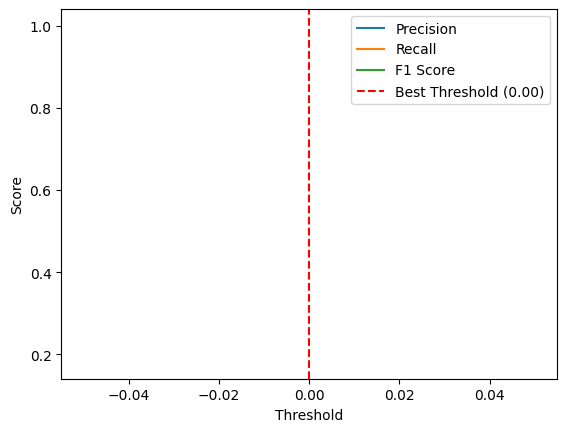

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Calculate precision and recall for all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_train, y_pred)

# Calculate F1 score for each threshold
# Note: We add 1e-9 to the denominator to avoid division by zero
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# Find the threshold that gives the best F1 score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {f1_scores[best_idx]:.4f}")

# Plot the curve
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1 Score")
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()